In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

# Table of Contents
* [Lecture 2D - Introduction to Time Series Data](#Lecture-8---Introduction-to-Time-Series-Data)
	* &nbsp;
		* [Content](#Content)
		* [Learning Outcomes](#Learning-Outcomes)
* [Importing Time Series Data](#Importing-Time-Series-Data)
* [Converting into Time Series Data](#Converting-into-Time-Series-Data)
* [Filtering Time Series Data](#Filtering-Time-Series-Data)
* [Resampling](#Resampling)
	* &nbsp;
		* [Moving (rolling/running) statistics](#Moving-%28rolling/running%29-statistics)
	* [Shift operations](#Shift-operations)
		* [Exercise:](#Exercise:)


# Lecture 2D - Introduction to Time Series Data

---

### Content

1. Importing time series data
2. Time series data types and conversions
3. Time series filtering
4. Time series resampling
5. Plotting time series

### Learning Outcomes

At the end of this lecture, you should be able to:

* import time series data
* convert datasets into appropriate time series data types
* filter dataframes based on time series conditions
* perform resampling of time series data
* perform running averages on time series data
* visualise time series data

The overall goal of Pandas is that of becoming "the most powerful and flexible open source data analysis manipulation tool available in any language", and it is already well on its way toward realizing this. One of the domains where Pandas has been excelling and has become a proven a tool is in the domain of time series data analysis. 

Time series data is a sequence of data points that comprises of measurements made over a time interval, where the time interval is continuous, having the same distance between consecutive data points, while generating at most one data point for each given moment in time.

Time series analysis is an substantive topic. The aim here will be to provide a brief introduction on how to process, manipulate and visualise time series data using a small subset of Pandas capabilities.

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from pylab import rcParams #this module gives us some controls over plot rendering attributes
rcParams['figure.figsize'] = 15, 10

In [102]:
#this line enables the plots to be embedded into the notebook
%matplotlib inline

# Importing Time Series Data

Below is a dataset extracted from Yahoo Finance showing the daily Apple stock price movements from 1980 to February 2016.

In [103]:
ts_data = pd.read_csv('apple.csv')
#ts_data.head()

In [104]:
ts_data

,Date,Open,High,Low,Close,Adj Close,Volume
0,9/29/2014,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
1,10/6/2014,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2,10/13/2014,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
3,10/20/2014,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
4,10/27/2014,104.849998,108.040001,104.699997,108.000000,101.380676,220230600
...,...,...,...,...,...,...,...
179,3/5/2018,175.210007,180.000000,174.270004,179.979996,179.979996,139852700
180,3/12/2018,180.289993,183.500000,177.619995,178.020004,178.020004,155417500
181,3/19/2018,177.320007,177.470001,164.940002,164.940002,164.940002,172670700
182,3/26/2018,168.070007,175.149994,165.190002,167.779999,167.779999,157898400


Notice that the data that we imported has the order of observations in a descending order in respect to Date. We will deal with this later.

Examine the data types for each of the columns.

In [105]:
ts_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       184 non-null    object 
 1   Open       184 non-null    float64
 2   High       184 non-null    float64
 3   Low        184 non-null    float64
 4   Close      184 non-null    float64
 5   Adj Close  184 non-null    float64
 6   Volume     184 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 10.2+ KB


Notice that the 'Date' column is an 'object' data type. This means that it has been interepreted as a 'string' rather than as a 'date' data type.

# Converting into Time Series Data

Below is an example of how we can convert a column that is interpreted as a string, into a datetime datatype.

In [106]:
ts_data['Date'] = pd.to_datetime(ts_data['Date'], format='%m/%d/%Y')
ts_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       184 non-null    datetime64[ns]
 1   Open       184 non-null    float64       
 2   High       184 non-null    float64       
 3   Low        184 non-null    float64       
 4   Close      184 non-null    float64       
 5   Adj Close  184 non-null    float64       
 6   Volume     184 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 10.2 KB


Notice the 'format' specification and how it fits exactly the format of the original string.

In [107]:
ts_data.info()
ts_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       184 non-null    datetime64[ns]
 1   Open       184 non-null    float64       
 2   High       184 non-null    float64       
 3   Low        184 non-null    float64       
 4   Close      184 non-null    float64       
 5   Adj Close  184 non-null    float64       
 6   Volume     184 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 10.2 KB


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600


The Date column is now a datetime64 data type. Notice that the appearance of the Date column has not changed, which is why it is important to check that the data types are as you would like them to be for each column.



**Exercise:** Use the pd.read_clipboard() function to read the below data into a dataframe. Then convert the column Date into a datetime data type that has the format of Year/Month/Day as above:  

In [108]:
#ts_data['Date'].apply(lambda x: x.strftime('%d/%m/%Y'))
d = pd.read_clipboard()
d

,Date
0,03/02/2016
1,02/02/2016
2,01/02/2016
3,29/01/2016
4,28/01/2016
5,27/01/2016
6,26/01/2016
7,25/01/2016
8,22/01/2016
9,21/01/2016


In [24]:
ts_data = pd.DataFrame(pd.to_datetime(d['Date'], format='%d/%m/%Y'))

In [109]:
type(ts_data)

pandas.core.frame.DataFrame

We can perform more powerful manipulation and processing if we make the Date column the index.

In [110]:
ts_data = ts_data.set_index(['Date'])
ts_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600


It is important to know how to manually convert columns into datetime and make them into a dataframe index; however, when reading in a csv file, we can do all of the above automatically in future by specifying a couple of parameters. 

In [111]:
ts_data = pd.read_csv('apple.csv', index_col='Date', parse_dates=True)
ts_data.info()
ts_data.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 184 entries, 2014-09-29 to 2018-03-29
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       184 non-null    float64
 1   High       184 non-null    float64
 2   Low        184 non-null    float64
 3   Close      184 non-null    float64
 4   Adj Close  184 non-null    float64
 5   Volume     184 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 10.1 KB


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600


# Filtering Time Series Data

In [112]:
ts_data['2016']

<ipython-input-112-c6881b0cdb1e>:1: FutureWarning: Indexing a DataFrame with a datetimelike index using a single string to slice the rows, like `frame[string]`, is deprecated and will be removed in a future version. Use `frame.loc[string]` instead.
  ts_data['2016']


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-01-04,102.610001,105.849998,96.430000,96.959999,92.969490,343790200
2016-01-11,98.970001,101.190002,95.360001,97.129997,93.132492,303513300
2016-01-18,98.410004,101.459999,93.419998,101.419998,97.245926,243384100
2016-01-25,101.519997,101.529999,92.389999,97.339996,93.333847,380336500
2016-02-01,96.470001,97.330002,93.690002,94.019997,90.150482,217154800
2016-02-08,93.129997,96.349998,92.589996,93.989998,90.610756,231122300
2016-02-15,95.019997,98.889999,94.610001,96.040001,92.587051,168316300
2016-02-22,96.309998,98.019997,93.320000,96.910004,93.425774,159052900
2016-02-29,96.860001,103.750000,96.650002,103.010002,99.306450,201803800


In [113]:
ts_data['2016-2']

<ipython-input-113-2c356ccbbc4a>:1: FutureWarning: Indexing a DataFrame with a datetimelike index using a single string to slice the rows, like `frame[string]`, is deprecated and will be removed in a future version. Use `frame.loc[string]` instead.
  ts_data['2016-2']


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-02-01,96.470001,97.330002,93.690002,94.019997,90.150482,217154800
2016-02-08,93.129997,96.349998,92.589996,93.989998,90.610756,231122300
2016-02-15,95.019997,98.889999,94.610001,96.040001,92.587051,168316300
2016-02-22,96.309998,98.019997,93.320000,96.910004,93.425774,159052900
2016-02-29,96.860001,103.750000,96.650002,103.010002,99.306450,201803800


In [114]:
ts_data.loc['2016-2']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-02-01,96.470001,97.330002,93.690002,94.019997,90.150482,217154800
2016-02-08,93.129997,96.349998,92.589996,93.989998,90.610756,231122300
2016-02-15,95.019997,98.889999,94.610001,96.040001,92.587051,168316300
2016-02-22,96.309998,98.019997,93.320000,96.910004,93.425774,159052900
2016-02-29,96.860001,103.750000,96.650002,103.010002,99.306450,201803800


**Exercise:** Filter the above dataframe to only display values from October 2015 to December 2015. 

In [115]:
ts_data['2016-1':'2015-10' ]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


Given that the index is in the 'wrong' order, it makes it somewhat less intuitive to work with.

We can reorder the index to make things easier.

In [74]:
ts_data.sort_index(ascending=True, inplace=True)
ts_data.head()

,Open,High,Low,Close,Adj Close,Volume,shifted
Date,,,,,,,
2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700,NaN
2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200,93.514290
2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800,94.556244
2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900,91.683792
2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600,98.771042


**Exercise:** Filter the above dataframe to only display values after January 15 2015.


In [116]:
ts_data['2016-1-15':]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-01-18,98.410004,101.459999,93.419998,101.419998,97.245926,243384100
2016-01-25,101.519997,101.529999,92.389999,97.339996,93.333847,380336500
2016-02-01,96.470001,97.330002,93.690002,94.019997,90.150482,217154800
2016-02-08,93.129997,96.349998,92.589996,93.989998,90.610756,231122300
2016-02-15,95.019997,98.889999,94.610001,96.040001,92.587051,168316300
...,...,...,...,...,...,...
2018-03-05,175.210007,180.000000,174.270004,179.979996,179.979996,139852700
2018-03-12,180.289993,183.500000,177.619995,178.020004,178.020004,155417500
2018-03-19,177.320007,177.470001,164.940002,164.940002,164.940002,172670700


Filtering can also be done through a *truncate()*. Truncate is simply a convenience function that is equivalent to slicing. Below is an example of filtering data to just December 2015 and January 2016 observations:


In [76]:
ts_data.truncate(before='2015-12-1', after='2016-1-31')

,Open,High,Low,Close,Adj Close,Volume,shifted
Date,,,,,,,
2015-12-07,118.980003,119.860001,112.849998,113.180000,108.521950,188745500,114.131180
2015-12-14,112.180000,112.800003,105.809998,106.029999,101.666199,315106400,108.521950
2015-12-21,107.279999,109.000000,105.570000,108.029999,103.583900,126607800,101.666199
2015-12-28,107.589996,109.430000,104.820000,105.260002,100.927895,123484500,103.583900
2016-01-04,102.610001,105.849998,96.430000,96.959999,92.969490,343790200,100.927895
2016-01-11,98.970001,101.190002,95.360001,97.129997,93.132492,303513300,92.969490
2016-01-18,98.410004,101.459999,93.419998,101.419998,97.245926,243384100,93.132492
2016-01-25,101.519997,101.529999,92.389999,97.339996,93.333847,380336500,97.245926


**Exercise:** Use the truncate function to filter the above dataframe to only display values after November 2015.

In [77]:
ts_data.truncate(after='2016-1-31')

,Open,High,Low,Close,Adj Close,Volume,shifted
Date,,,,,,,
2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700,NaN
2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200,93.514290
2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800,94.556244
2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900,91.683792
2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600,98.771042
...,...,...,...,...,...,...,...
2015-12-28,107.589996,109.430000,104.820000,105.260002,100.927895,123484500,103.583900
2016-01-04,102.610001,105.849998,96.430000,96.959999,92.969490,343790200,100.927895
2016-01-11,98.970001,101.190002,95.360001,97.129997,93.132492,303513300,92.969490


# Resampling

Resampling transforms time series data into a different frequency (e.g., converting hourly data into daily data). Pandas provide and easy way to perform these frequency conversion operations which are extremely common in  financial applications, but not limited to them only.

Resampling requires that 1) the resampling time period is specified, 2) the method to apply to the resampled data (default is mean). For those familiar with SQL, resampling is essentially a time-based **groupby** operation, followed by a reduction method on each of its groups. 

Reduction can be: 'mean','median','sum','min','max','first','last','ohlc' or other available numpy/user defined transformation.

A variety of built-in reduction time frequencies are available:

In [49]:
ts_data['2015'].resample('M').agg('mean')

<ipython-input-49-912c3cde320e>:1: FutureWarning: Indexing a DataFrame with a datetimelike index using a single string to slice the rows, like `frame[string]`, is deprecated and will be removed in a future version. Use `frame.loc[string]` instead.
  ts_data['2015'].resample('M').agg('mean')


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-31,110.617498,114.950001,106.339998,112.035002,105.624401,312859800
2015-02-28,123.527502,127.772503,122.010000,125.992502,119.141426,284133800
2015-03-31,126.452000,128.725999,123.192000,124.931999,118.248283,242296720
2015-04-30,127.679998,130.465000,124.635000,127.769998,120.934446,245451650
2015-05-31,129.467502,131.485004,126.414999,129.802500,123.245260,223909875
2015-06-30,127.645998,129.323999,126.136002,127.121998,120.823709,187192480
2015-07-31,126.007500,128.182501,121.610001,124.674999,118.497944,250014350
2015-08-31,112.194000,117.609999,105.348000,111.959999,106.795186,369588640
2015-09-30,113.962500,115.590000,110.330000,113.187498,108.066551,271632825


**Exercise:** Resample the date above dataframe based on the quarter end frequency on data between 1990 and 2010 using the median as the reduction method. 

In [51]:
#ts_data['1990':'2010'].resample('Q', how='mean')
ts_data['2015':'2016'].resample('Q').agg('mean')


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-03-31,120.680000,124.193847,117.643076,121.290001,114.638825,2.768814e+08
2015-06-30,128.216922,130.340001,125.760000,128.146153,121.602875,2.164160e+08
2015-09-30,116.988461,120.241538,111.884616,116.249999,110.787224,3.026563e+08
2015-12-31,114.455384,117.020001,111.164615,114.136923,109.256262,2.048111e+08
2016-03-31,99.656154,102.443846,96.935384,100.050768,96.258754,2.195239e+08
2016-06-30,99.522308,101.521539,96.629232,98.316154,95.127874,1.963017e+08
2016-09-30,104.770770,107.814616,103.510770,106.294616,103.450939,1.736844e+08
2016-12-31,113.135385,115.242308,110.980769,113.329999,110.863632,1.551479e+08


**Exercise:** Describe what the output of the below means? 

In [52]:
#ts_data['Adj Close'].resample('A').agg('ohlc')

,open,high,low,close
Date,,,,
2014-12-31,93.514290,112.124863,91.683792,103.074181
2015-12-31,105.600830,125.973259,99.925285,100.927895
2016-12-31,92.969490,114.709305,87.796822,113.524132
2017-12-31,115.572708,174.299362,115.572708,168.542831
2018-12-31,174.289398,179.979996,155.774887,167.779999


Visualising the data is as simple as calling *plot()* on the required column:

In [53]:
ts_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600


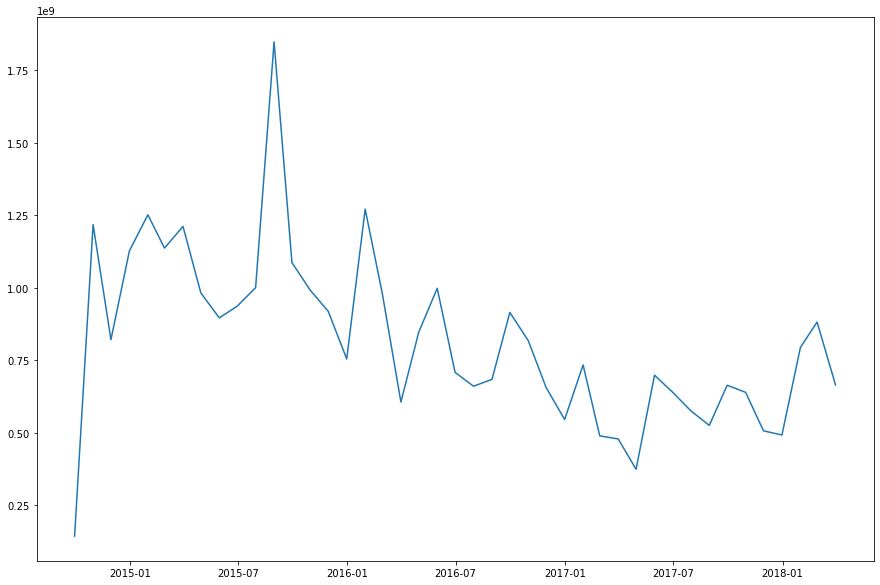

In [79]:
#ts_data[['Volume']].resample('M', how='sum').plot()
plt.plot( ts_data[['Volume']].resample('M').agg('sum'))

We can increase the size of the plot and render several plots at the same time:

array([<AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>,
       <AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>,
       <AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>],
      dtype=object)

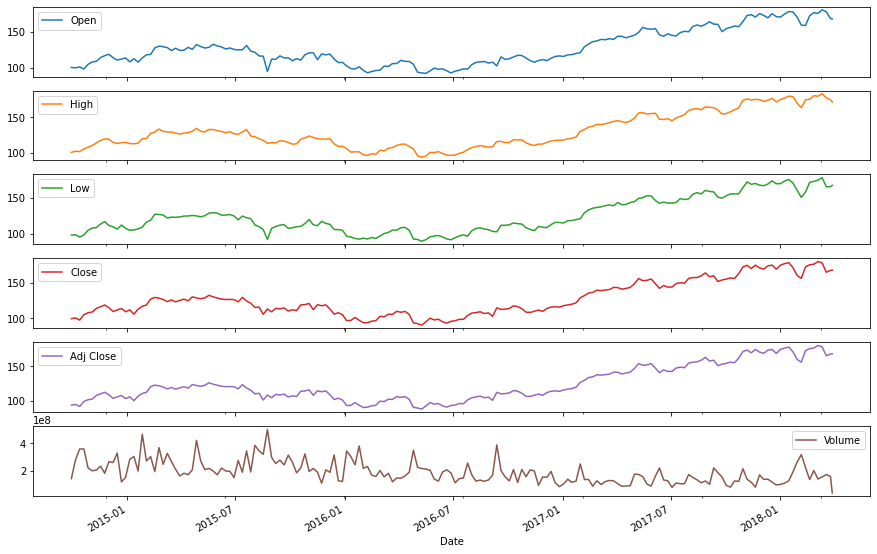

In [55]:
rcParams['figure.figsize'] = 15, 10
ts_data.plot(subplots=True)

**Exercise:** The period leading to the recent global financial crisis and the immediate aftermath are interesting to look at into more detail from the perspective of the adjusted closing price and the total volume of shares traded for Apple. Render separately two plots for these columns for data from 2007 to 2010.

array([<AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>],
      dtype=object)

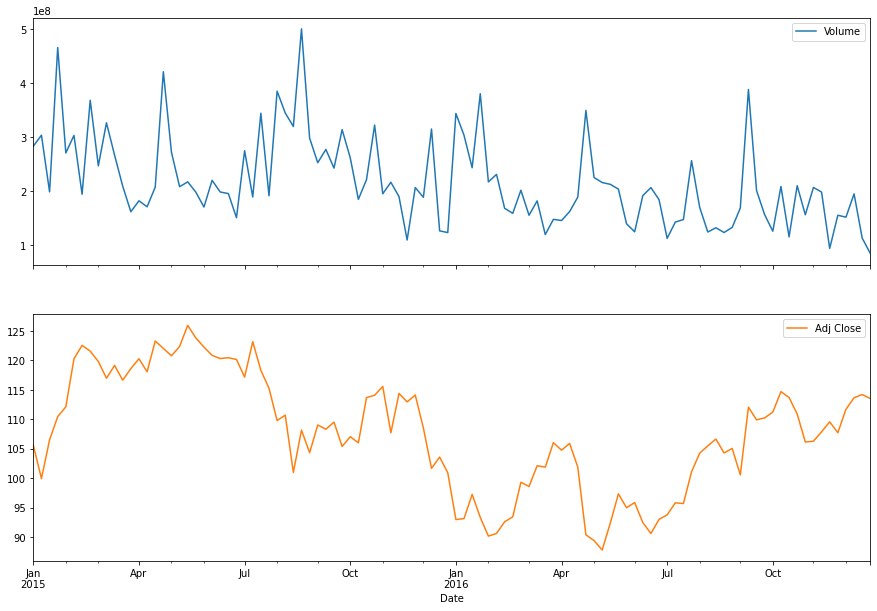

In [82]:
ts_data[['Volume','Adj Close']].loc['2015':'2016'].plot(subplots=True)

We can use resampling to reduce the frequency of Apple share trading to annual and plot the historical variation between the min/max and the mean prices for Apple shares in each year:

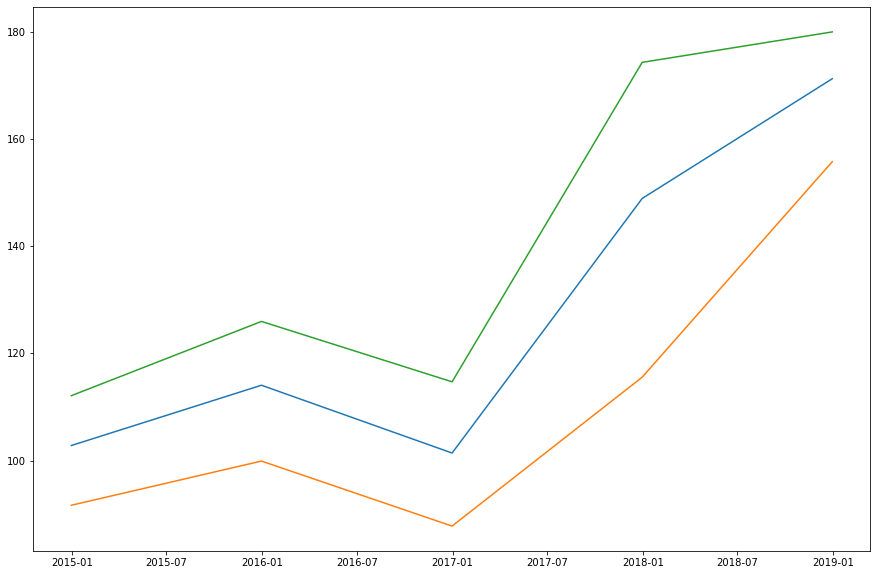

In [83]:
plt.plot( ts_data[['Adj Close']].resample('A').agg('mean'))
plt.plot( ts_data[['Adj Close']].resample('A').agg('min'))
plt.plot( ts_data[['Adj Close']].resample('A').agg('max'))


**Exercise:** Render a graph that is the same as above, only this time use a 5 year frequency:

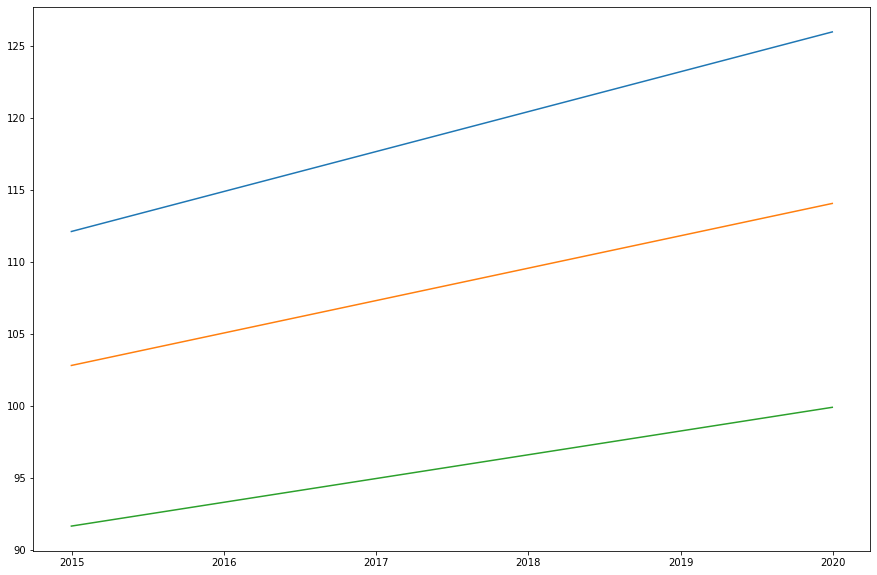

In [84]:
plt.plot(ts_data[['Adj Close']].loc[:'2015'].resample('5A').agg('max'))
plt.plot(ts_data[['Adj Close']].loc[:'2015'].resample('5A').agg('mean'))
plt.plot(ts_data[['Adj Close']].loc[:'2015'].resample('5A').agg('min'))


#ts_data[['Adj Close']].ix[:'2015'].resample("5A", how=['mean', np.min, np.max]).plot()

### Moving (rolling/running) statistics

A rolling average is a series of averages of different subsets of the full data set as defined by a filter window.

It is widely used indicator that helps smooth out price movements by filtering out the noise from random fluctuations.

In [88]:
pd.rolling_mean(ts_data[['Adj Close']], window=5).head(10)

AttributeError: module 'pandas' has no attribute 'rolling_mean'

<AxesSubplot:xlabel='Date'>

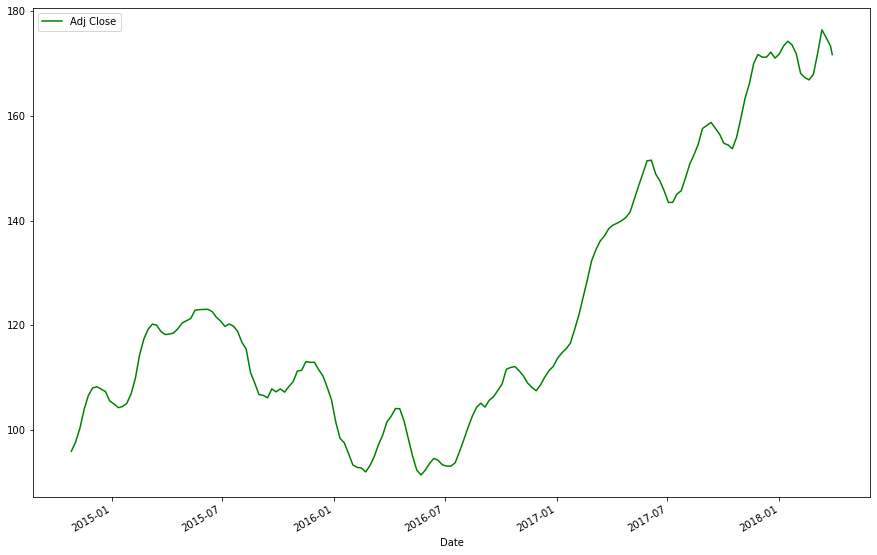

In [93]:
ts_data[['Adj Close']].rolling(5).mean().plot(style='-g')

**Exercise:** Generate rolling mean plots on the Volume column for the Apple share trading data. Determine the most 'useful' window size.

<AxesSubplot:xlabel='Date'>

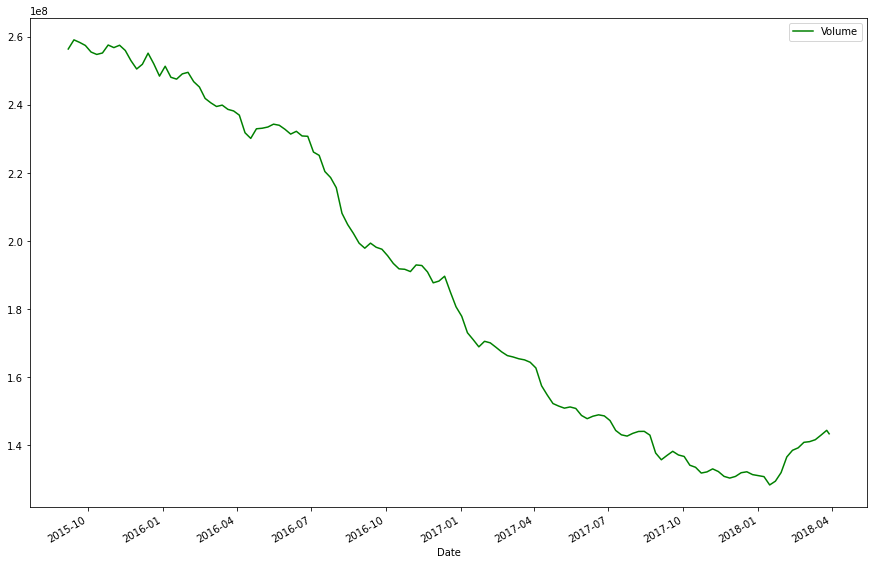

In [95]:
ts_data[['Volume']].rolling(50).mean().plot(style='-g')

##  Shift operations

“Shifting” refers to moving data backward and forward through time. Both Series and
DataFrame have a  shift method for performing this operation.

If we wanted to calculate the difference in oil price from one year to the next (something very common in time series analysis), then pandas provides for us a method called shift(), which allows us to select a column and move the data in it up or down by a given amount. 

In our case, we want to see the difference between the values in price from one year to the next so we will shift the columns by one.

In [96]:
ts_data.head()

,Open,High,Low,Close,Adj Close,Volume,shifted
Date,,,,,,,
2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700,NaN
2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200,93.514290
2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800,94.556244
2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900,91.683792
2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600,98.771042


In [97]:

ts_data['shifted'] = ts_data['Adj Close'].shift(1)
ts_data

,Open,High,Low,Close,Adj Close,Volume,shifted
Date,,,,,,,
2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700,NaN
2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200,93.514290
2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800,94.556244
2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900,91.683792
2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600,98.771042
...,...,...,...,...,...,...,...
2018-03-05,175.210007,180.000000,174.270004,179.979996,179.979996,139852700,176.210007
2018-03-12,180.289993,183.500000,177.619995,178.020004,178.020004,155417500,179.979996
2018-03-19,177.320007,177.470001,164.940002,164.940002,164.940002,172670700,178.020004


**Exercise**: Plot the positive and negative fluctuations of the oil price from year to year for the above dataset.

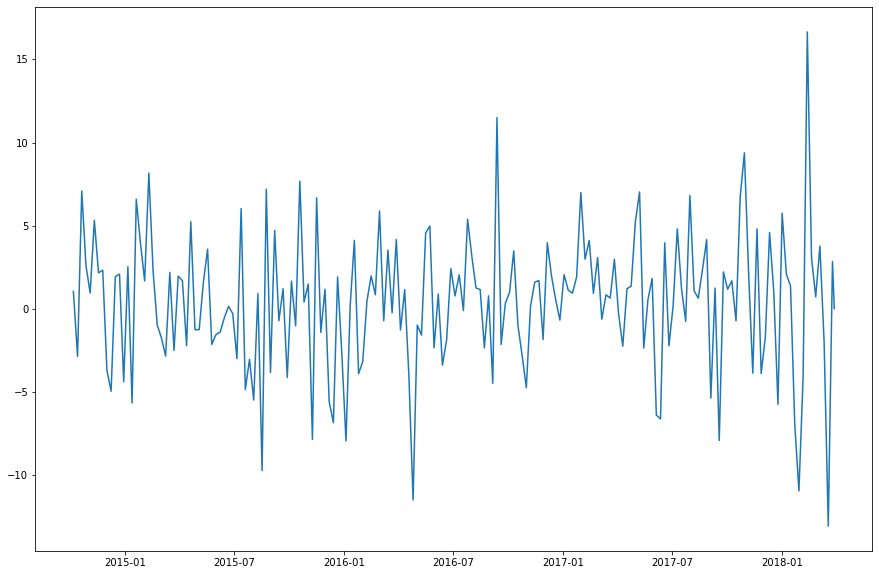

In [87]:
plt.plot(ts_data['Adj Close'] - ts_data.shifted)

### Exercise: 

Read in the oil_price.csv dataset.

Convert the 'Year' feature into datetime and set it as the index.

Perform the same analysis as above using the 'shift' function and plot the InflationAdjustedPrice difference from one year to the next.

In [1]:
%%javascript
require(['base/js/utils'],
function(utils) {
   utils.load_extensions('calico-spell-check', 'calico-document-tools', 'calico-cell-tools');
});

<IPython.core.display.Javascript object>